In [1]:
model_name = "AlexNet-ragdoll"
model_file = "alexnet"

import iree
import iree.compiler
import iree.runtime
import torch
import numpy as np
from torch import nn
from torchvision import models

import warnings
warnings.filterwarnings("ignore")

from timeit import timeit as ti
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

from ragdoll.compiler import *
from ragdoll.benchmark import *
import ragdoll

def get_dataframe(forward, backward, item):
    return pd.concat([
        pd.DataFrame({
            "time": forward,
            "pass": "Forward",
            "item": item
        }, index=[0]),
        pd.DataFrame({
            "time": backward,
            "pass": "Backward",
            "item": item
        }, index=[0]),
        pd.DataFrame({
            "time": forward + backward,
            "pass": "Full",
            "item": item
        }, index=[0]),
    ])

def timeit(stmt, n=100):
    return ti(stmt, globals=globals(), number=n) * 1000 / n

image = torch.randn(1, 3, 224, 224)
image_np = image.detach().cpu().numpy()
image_transposed = torch.randn(1, 224, 224, 3)
image_np_transposed = image_transposed.detach().cpu().numpy()
model = models.alexnet().train(False)
model.load_state_dict({k: torch.ones_like(v) * 0.23421 for k, v in model.state_dict().items()})
output = model(image)
grad = torch.randn_like(output)
grad_np = grad.cpu().numpy()

BENCHMARK_REPEAT=111
df = pd.DataFrame()

In [2]:
# v1, transpose-conv-transpose => conv, if transpose can eliminate
# avgpool 7x7x512, 1x1x512 => reshape 49x512, reduce_sum
_model_file = model_file+".mlir.v1.heuristic"
target_file = _model_file + ".improve-model"

!iree-compile {_model_file} \
-o {target_file}.vmfb \
--iree-hal-target-backends=cuda \
--iree-hal-benchmark-dispatch-repeat-count={BENCHMARK_REPEAT} \
--iree-hal-cuda-llvm-target-arch=sm_86
v1 = target_file+".vmfb"

def load_executable(fb_file):
    config = iree.runtime.system_api.Config("cuda")
    vmi = iree.runtime.VmInstance()
    # replace compile with args of fatbin type
    # fb_file = ragdoll.compile(mlir, "gpu", "input", "codegen", benchmark=True)
    with open(fb_file, 'rb') as f:
        binary_data = f.read()
    vmm = iree.runtime.VmModule.from_flatbuffer(vmi, binary_data)
    vmo = iree.runtime.load_vm_module(vmm, config)
    return vmo
v1_fb = load_executable(v1)

In [3]:
f1 = timeit("v1_fb.forward(image_np_transposed)") / BENCHMARK_REPEAT
print('forward in timeit: ', f1)
b1 = timeit("v1_fb.dforward(grad_np)") /  BENCHMARK_REPEAT
print('backward in timeit: ', b1)
df = pd.concat([df, get_dataframe(f1, b1, "Nabla-v1")])
print(df)

forward in timeit:  0.24135461236509653
backward in timeit:  0.8502517134655971
       time      pass      item
0  0.241355   Forward  Nabla-v1
0  0.850252  Backward  Nabla-v1
0  1.091606      Full  Nabla-v1


In [5]:
# original model
_model_file = model_file+".mlir.v0.heuristic"
target_file = _model_file + ".improve-model"

!iree-compile {_model_file} \
-o {target_file}.vmfb \
--iree-hal-target-backends=cuda \
--iree-hal-benchmark-dispatch-repeat-count={BENCHMARK_REPEAT} \
--iree-hal-cuda-llvm-target-arch=sm_86
v0 = target_file+".vmfb"

def load_executable(fb_file):
    config = iree.runtime.system_api.Config("cuda")
    vmi = iree.runtime.VmInstance()
    # replace compile with args of fatbin type
    # fb_file = ragdoll.compile(mlir, "gpu", "input", "codegen", benchmark=True)
    with open(fb_file, 'rb') as f:
        binary_data = f.read()
    vmm = iree.runtime.VmModule.from_flatbuffer(vmi, binary_data)
    vmo = iree.runtime.load_vm_module(vmm, config)
    return vmo
v0_fb = load_executable(v0)

In [6]:
f1 = timeit("v0_fb.forward(image_np)") / BENCHMARK_REPEAT
print('forward in timeit: ', f1)
b1 = timeit("v0_fb.dforward(grad_np)") /  BENCHMARK_REPEAT
print('backward in timeit: ', b1)
df = pd.concat([df, get_dataframe(f1, b1, "Nabla-v0")])
print(df)

forward in timeit:  0.3054502783427099
backward in timeit:  0.8735353978736712
       time      pass      item
0  0.241355   Forward  Nabla-v1
0  0.850252  Backward  Nabla-v1
0  1.091606      Full  Nabla-v1
0  0.305450   Forward  Nabla-v0
0  0.873535  Backward  Nabla-v0
0  1.178986      Full  Nabla-v0


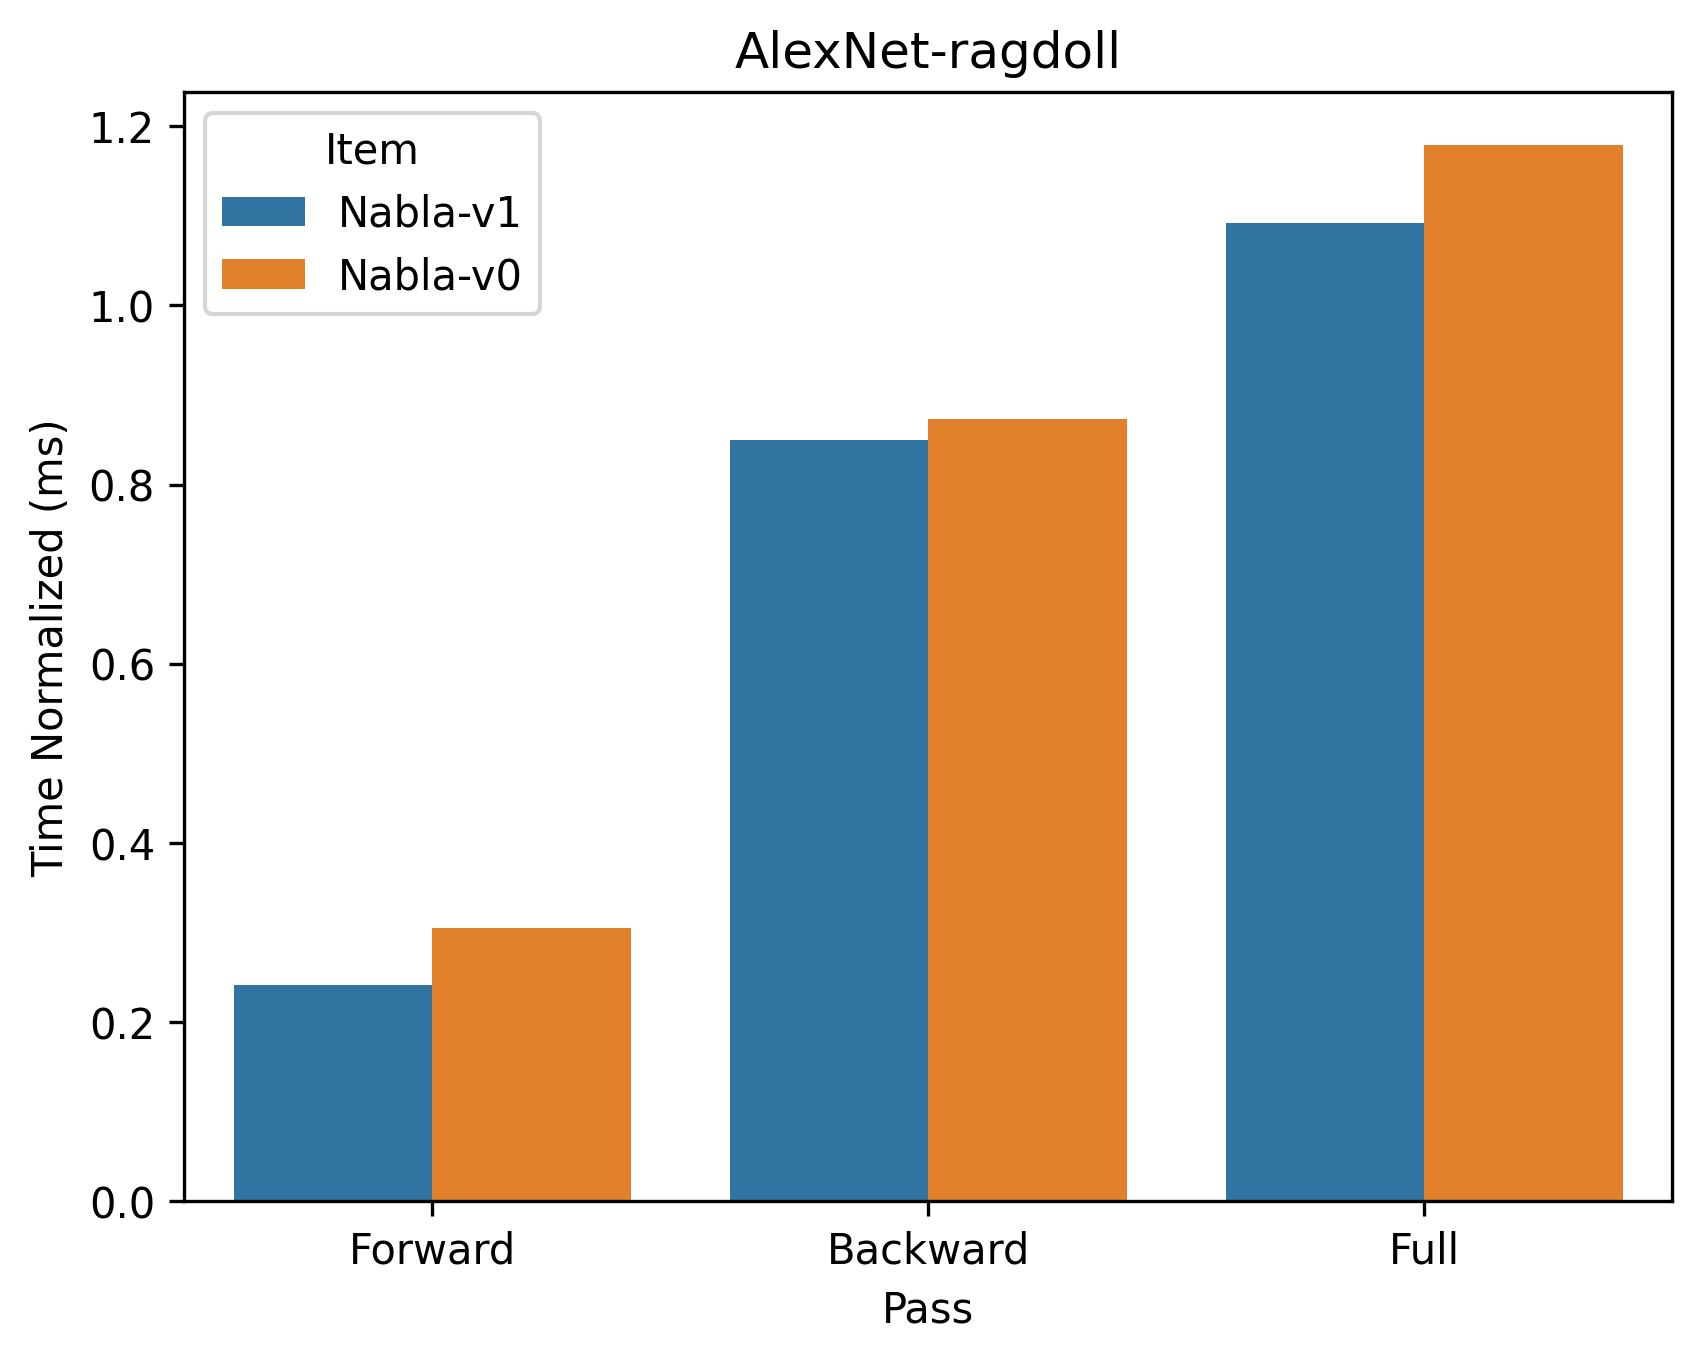

In [7]:
df.style.hide(axis="index")
plt.rcParams["figure.dpi"] = 300

sns.barplot(df, x="pass", y="time", hue="item")
plt.xlabel("Pass")
plt.ylabel("Time Normalized (ms)")
plt.legend().set_title("Item")
plt.title(model_name)

plt.savefig(f"{model_name}-time.png")